# Heart Disease UCI — EDA & Preprocessing
**MLOps Assignment 01 (AIMLCZG523) — Task 1: Data Acquisition & Exploratory Data Analysis**

This notebook follows the assignment's dataset and EDA requirements exactly:

- **Dataset**: Heart Disease UCI Dataset (UCI Machine Learning Repository, id=45 — Cleveland subset), 14+ features (age, sex, blood pressure, cholesterol, etc.) and a binary target.
- **EDA required**: histograms, correlation heatmap, class distribution plot, missing value analysis, feature relationship analysis (per assignment FAQ).
- **Preprocessing required**: handle missing values, encode categorical variables, scale numerical features, split train/test data properly (per assignment FAQ).

Output of this notebook: a cleaned dataset and a fitted `ColumnTransformer` preprocessing pipeline saved to disk, ready for Task 2 (Feature Engineering & Model Development).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 2. Load the Dataset

Loads the raw CSV produced by `src/data_download.py` (via the official `ucimlrepo` package,
UCI Heart Disease dataset id=45). If you haven't run that script yet, run it first from the
project root:

```bash
python src/data_download.py
```


In [2]:
RAW_PATH = "../data/raw/heart_disease_raw.csv"

df = pd.read_csv(RAW_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 3. Target Variable

The raw UCI dataset encodes `num` as **0–4** (0 = no disease, 1–4 = increasing severity of
disease). The assignment requires a **binary target** (presence/absence of heart disease),
so we explicitly convert:

- `num == 0`  → `target = 0` (no disease)
- `num >= 1`  → `target = 1` (disease present)

This conversion is done here, explicitly and visibly, rather than silently in the download
script, so it's documented for the report.


In [5]:
print("Raw target value counts (0-4 severity scale):")
print(df["num"].value_counts().sort_index())

df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

print("\nBinary target value counts:")
print(df["target"].value_counts())


Raw target value counts (0-4 severity scale):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target value counts:
target
0    164
1    139
Name: count, dtype: int64


## 4. Missing Value Analysis

Per the FAQ: *"You should include: ... Missing value analysis"*. The Cleveland Heart Disease
dataset has a small number of genuine missing values, historically in the `ca` and `thal`
columns.


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct.round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

print("Columns with missing values:")
missing_summary


Columns with missing values:


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


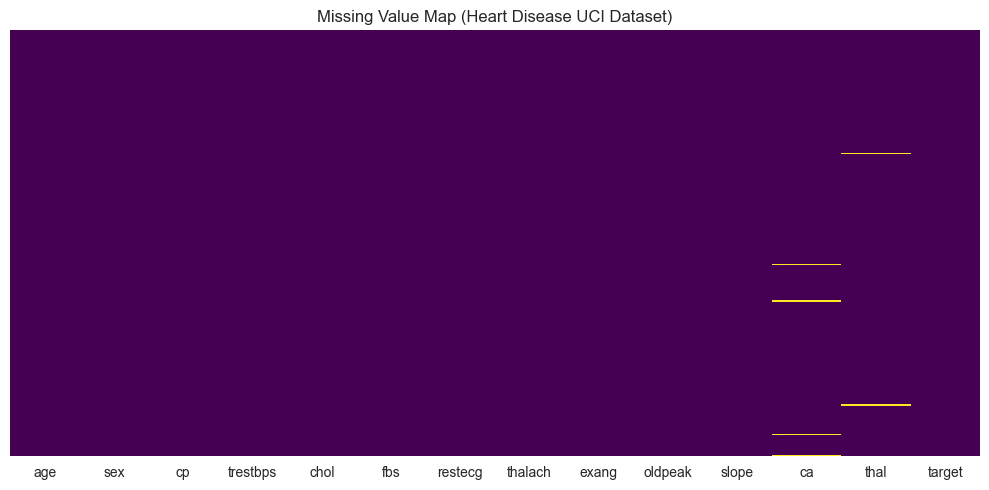

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (Heart Disease UCI Dataset)")
plt.tight_layout()
plt.savefig("../report/missing_value_map.png", dpi=150)
plt.show()


## 5. Class Distribution

Per the FAQ: *"Class distribution plots"*. This shows whether the dataset is balanced or
imbalanced between the two target classes — relevant later for model evaluation choices
(e.g. whether accuracy alone is a trustworthy metric).


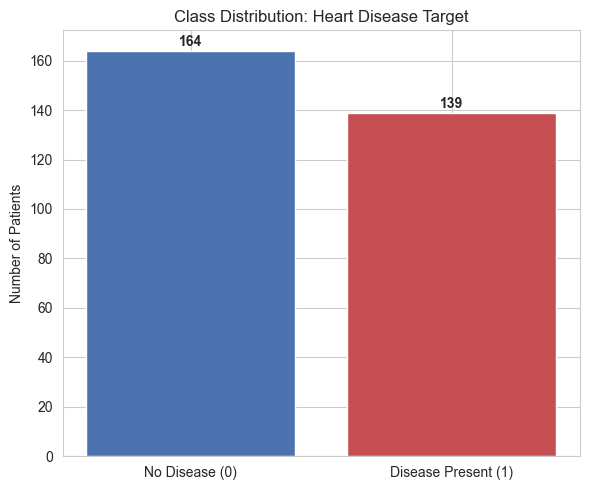

Class balance: 164 negative / 139 positive (45.9% positive rate)


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df["target"].value_counts().sort_index()
labels = ["No Disease (0)", "Disease Present (1)"]
colors = ["#4C72B0", "#C44E52"]

bars = ax.bar(labels, counts.values, color=colors)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             str(count), ha="center", fontweight="bold")

ax.set_ylabel("Number of Patients")
ax.set_title("Class Distribution: Heart Disease Target")
plt.tight_layout()
plt.savefig("../report/class_distribution.png", dpi=150)
plt.show()

print(f"Class balance: {counts[0]} negative / {counts[1]} positive "
      f"({counts[1] / len(df):.1%} positive rate)")


## 6. Feature Types

Splitting columns into numerical and categorical groups. This grouping drives both the
histograms below and the `ColumnTransformer` preprocessing pipeline in Section 9.

Categorical/ordinal-coded columns in this dataset (encoded as integers in the raw data):
`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`.
Truly continuous numerical columns: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`.


In [9]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


## 7. Histograms

Per the FAQ: *"Histograms"*. Distribution of every numerical feature.


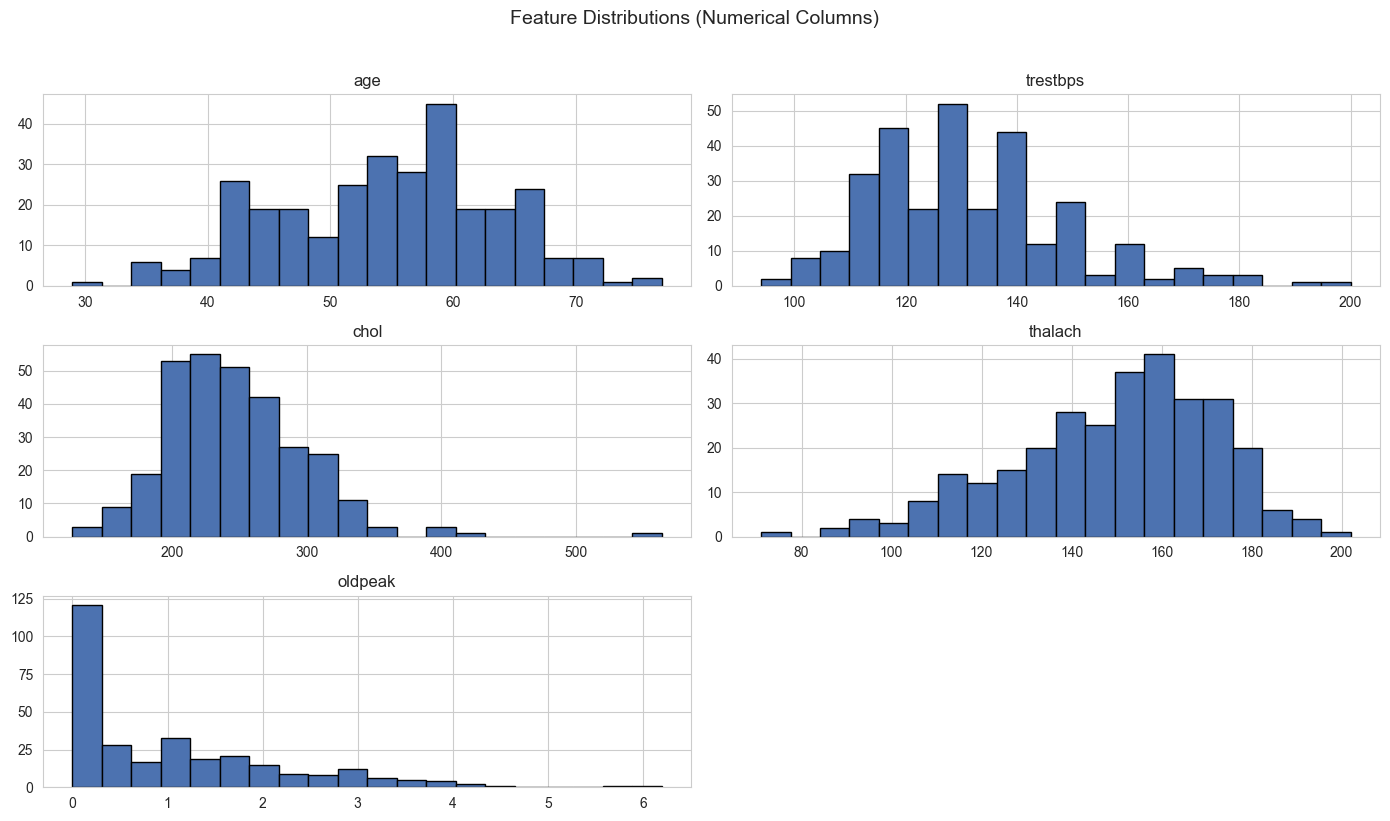

In [10]:
df[numerical_cols].hist(bins=20, figsize=(14, 8), color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions (Numerical Columns)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../report/feature_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Correlation Heatmap

Per the FAQ: *"Correlation heatmaps"*. Computed on numerical features plus the binary
target to see which continuous variables are most associated with disease presence.


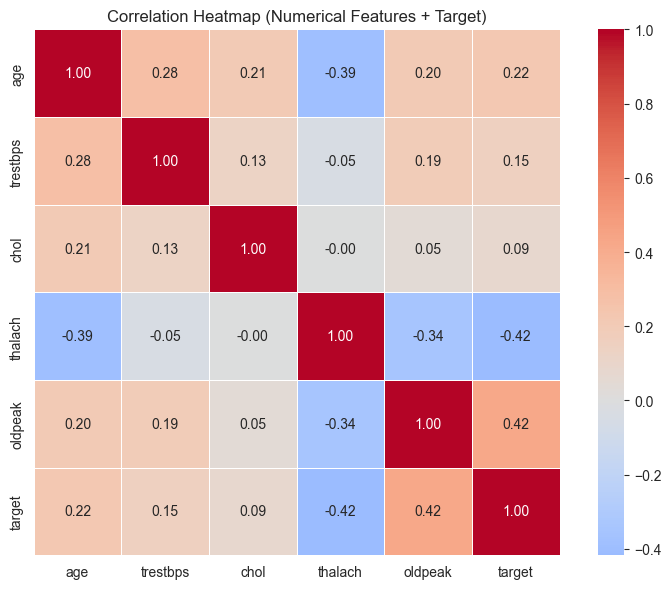

In [11]:
corr_cols = numerical_cols + ["target"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap (Numerical Features + Target)")
plt.tight_layout()
plt.savefig("../report/correlation_heatmap.png", dpi=150)
plt.show()


## 9. Feature Relationship Analysis

Per the FAQ: *"Feature relationship analysis"*. Boxplots of key numerical features split
by target class, plus a categorical feature breakdown, to see how individual features
relate to disease presence.


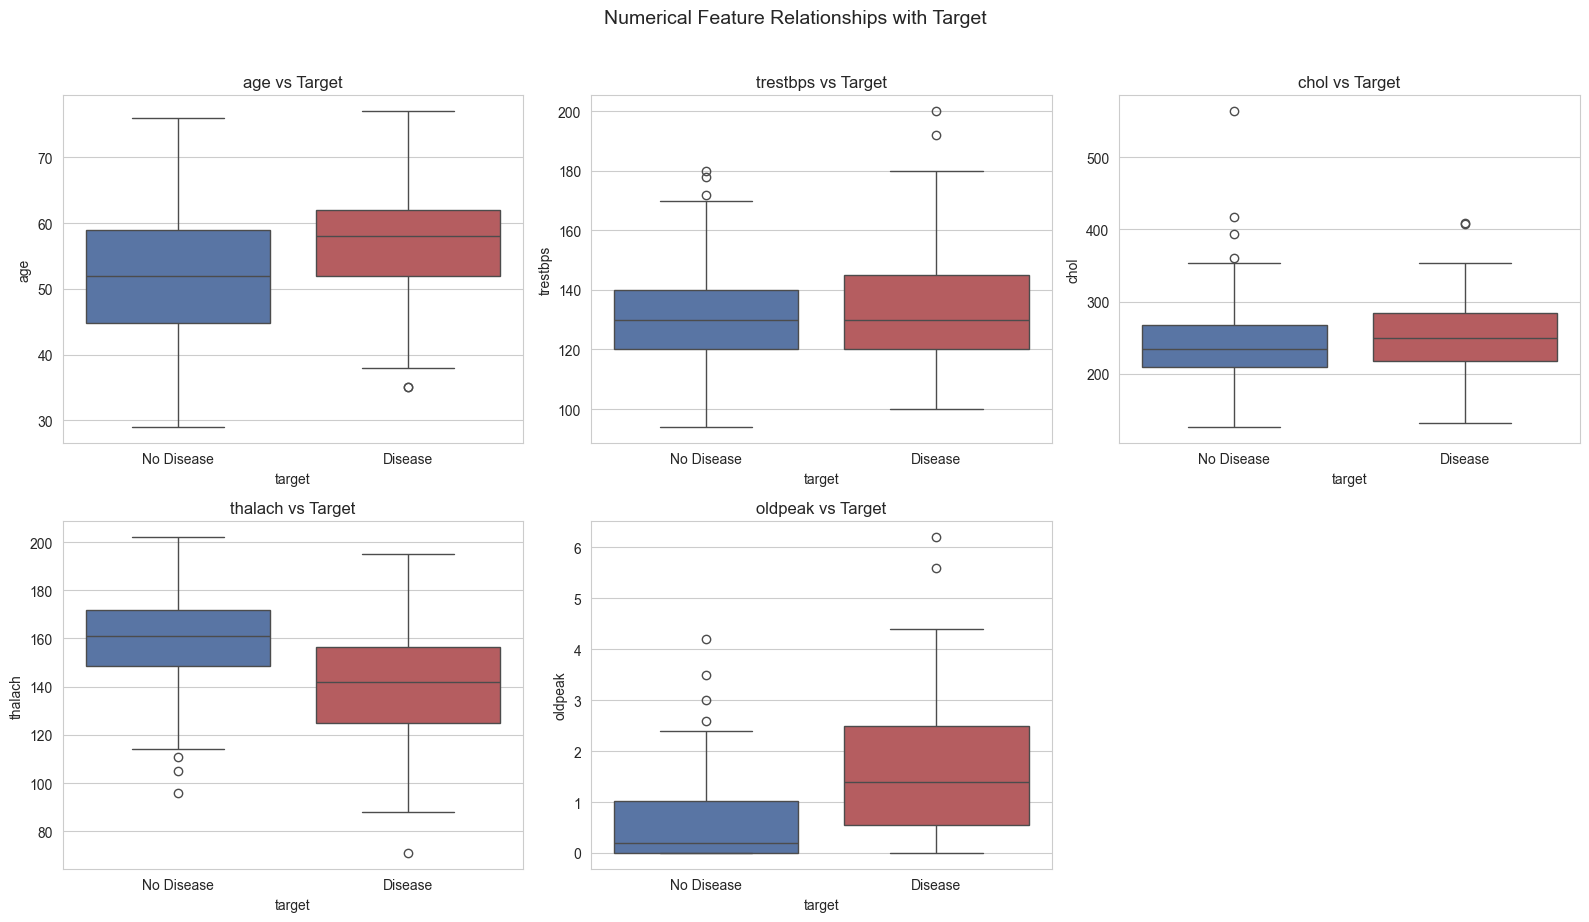

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x="target", y=col, hue="target", palette=colors,
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Disease", "Disease"])

# Remove the unused 6th subplot
fig.delaxes(axes[5])

plt.suptitle("Numerical Feature Relationships with Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../report/feature_relationships_numerical.png", dpi=150, bbox_inches="tight")
plt.show()


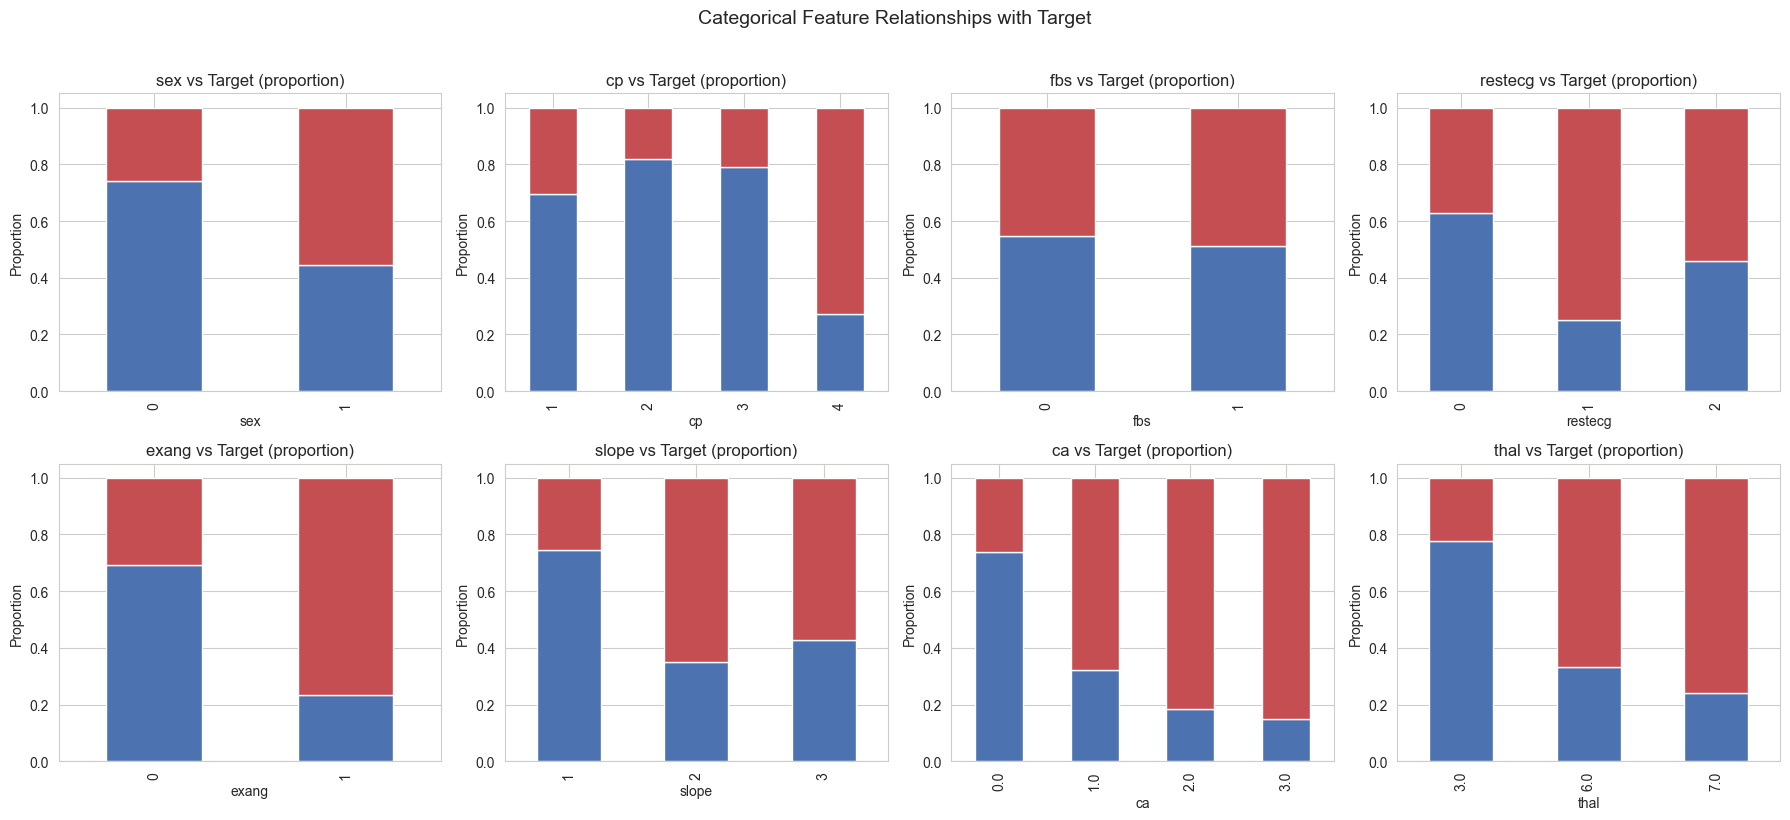

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df["target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=colors, legend=False)
    axes[i].set_title(f"{col} vs Target (proportion)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion")

plt.suptitle("Categorical Feature Relationships with Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../report/feature_relationships_categorical.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Preprocessing: Train/Test Split

Per the FAQ: *"Split train/test data properly"*. Split **before** fitting any imputer or
scaler, so no information from the test set leaks into preprocessing statistics (mean,
std, most-frequent category, etc.). Stratified on the target to preserve class balance
in both splits.


In [14]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"Test class balance:\n{y_test.value_counts(normalize=True)}")


Train shape: (242, 13), Test shape: (61, 13)
Train class balance:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64
Test class balance:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## 11. Preprocessing Pipeline: Impute, Encode, Scale

Per the FAQ: *"Handle missing values / Encode categorical variables / Scale numerical
features"*, and the Task 4 requirement that preprocessing be a **reusable pipeline**
(sklearn `Pipeline` + `ColumnTransformer`), so the exact same transformation can be
applied at inference time in the API.

- **Numerical columns**: median imputation + `StandardScaler`.
- **Categorical columns**: most-frequent imputation + `OneHotEncoder` (handles the
  missing `ca`/`thal` values and turns integer-coded categories into proper dummy
  variables instead of treating them as ordinal).


In [15]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Fit ONLY on training data to avoid leakage
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")


Processed train shape: (242, 28)
Processed test shape: (61, 28)


## 12. Save Cleaned Data & Preprocessing Pipeline

Saves everything Task 2 (modeling) and Task 4 (packaging/reproducibility) need:

- Cleaned raw-format train/test CSVs (pre-transform, human-readable, for reference)
- The **fitted** `preprocessor` object, so the identical transform can be reloaded in
  `src/train.py` and later in the FastAPI `/predict` endpoint at inference time.


In [16]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

X_train.assign(target=y_train.values).to_csv("../data/processed/train.csv", index=False)
X_test.assign(target=y_test.values).to_csv("../data/processed/test.csv", index=False)

joblib.dump(preprocessor, "../models/preprocessor.joblib")

print("Saved:")
print(" - ../data/processed/train.csv")
print(" - ../data/processed/test.csv")
print(" - ../models/preprocessor.joblib")


Saved:
 - ../data/processed/train.csv
 - ../data/processed/test.csv
 - ../models/preprocessor.joblib


## Summary

- Dataset: Heart Disease UCI (Cleveland, id=45), 303 rows, 13 features + binary target.
- Missing values found in `ca` and `thal` — handled via most-frequent imputation.
- Target converted from 0–4 severity scale to binary (0 = no disease, 1 = disease present).
- Class distribution, correlation heatmap, histograms, and feature-vs-target relationships
  all generated and saved to `report/` for use in the final written report.
- Train/test split done **before** fitting preprocessing to avoid data leakage.
- Reusable `ColumnTransformer` (median/most-frequent imputation + scaling + one-hot
  encoding) fitted and saved to `models/preprocessor.joblib` for Task 2 and the
  inference API.

**Next step: Task 2 — Feature Engineering & Model Development (`train.py`, MLflow tracking).**
